# 프로젝트1 : 손수설계하는 선형회귀, 당뇨병 수치를 맞춰보자!
##### 1. 데이터 준비 -> 2. 데이터 분할 -> 3. 함수 정의 -> 4. 모델 학습 -> 5. 성능 평가 -> 6. 특성 분석 -> 7. 결과 시각화

## (1) 라이브러리 호출

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## (2) 데이터 가져오기 

In [3]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data      
df_y = data.target

## (3) 모델에 입력할 데이터 X 준비하기

In [4]:
import numpy as np
X = np.array(df_X)    
print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


##### 입력값 X가 넘파이 배열(numpy array) 타입이고 배열 안의 데이터가 실수 형식

## (4) 모델에 예측할 데이터 y 준비하기

In [5]:
y = np.array(df_y)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


##### 예측값 y는 넘파이 배열(numpy array) 타입이고 배열 안의 데이터가 실수 형식

## (5) 데이터 크기 확인

In [6]:
print(f"X: {X.shape}, y: {y.shape}")

X: (442, 10), y: (442,)


##### 442명의 당뇨병 환자에 대해,X는 10가지 건강 정보를 담은 표이고,y는 각 환자의 당뇨 진행도 점수 목록이다

## (6) 결측치 확인

In [7]:
print(f"결측치: {np.isnan(X).sum() + np.isnan(y).sum()}개")

결측치: 0개


## (7) y 범위 확인 (예측할 값의 범위 파악)

In [8]:
print(f"당뇨 점수 범위: {y.min():.0f} ~ {y.max():.0f}")

당뇨 점수 범위: 25 ~ 346


##### 이 데이터셋 환자들의 당뇨 진행도 최소~최대 범위인데 25는 가장 당뇨가 덜 진행된 환자이고 346점은 가장 당뇨가 많이 진행된 환자

## (8) train 데이터와 test 데이터로 분리하기

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


##### X_train shape는 353명 × 10개 특성 = 입력 데이터, y_train shape는353명의 당뇨 점수 = 정답 데이터
##### X_test shape는 89명 × 10개 특성, 	y_test shape 89명의 당뇨 점수
##### 전체환자 442명중 80%인 353명을 훈련세트로 만들고, 20%인 89명을 테스트 세트로 만듬
##### 353명으로 패턴 학습하고, 89명으로 성능 검증 

## (9) 모델 준비하기

In [11]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


##### X_train.shape[1]은 특성 개수 확인(10), np.random.rand은 랜덤 숫자 10개 생성 w에 할당후 출력

## (10) 모델함수 정의

In [15]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i] # 각 특성 × 가중치
    predictions += b                   # 편향 더하기
    return predictions

##### 함수가 정의되지 않으면 환자 1명 예측할때마다 10줄식 작성해야 함
##### 그런데, scikit-learn은 내부적으로 위와 같은 함수를 이미 가지고 있다.

## (11) 손실함수 loss 정의하기

In [16]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

##### "예측값(a)과 실제값(b)이 얼마나 다른지를 숫자 하나로 표현하는 함수"

In [17]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

##### "모델의 예측값과 실제값 사이의 MSE 손실을 계산하는 함수"
#####  MSE와 분리한 이유는 "오차 계산 방식(MSE)과 모델 성능 평가 과정(loss)을 분리하여 재사용성과 유지보수성을 높이기 위해"

## (12) 기울기를 구하는 gradient 함수 구현하기

In [18]:
def gradient(X, W, b, y):
    N = len(y)                    # 데이터 개수
    y_pred = model(X, W, b)       # 예측값
    dW = 1/N * 2 * X.T.dot(y_pred - y)  # 가중치에 대한 기울기
    db = 2 * (y_pred - y).mean()        # 편향에 대한 기울기
    return dW, db

##### 그래디언트 함수는 "현재 W,b에서 손실을 가장 빠르게 줄일 수 있는 방향과 크기" 를 계산하여, 경사 하강법이 올바른 방향으로 학습할 수 있도록 안내하는 역할

## (13) 하이퍼 파라미터인 학습률 설정하기

In [19]:
LEARNING_RATE = 0.001

##### LEARNING_RATE = 0.001은 "한 번의 학습 단계에서 모델의 가중치를 얼마나 크게 업데이트할지 결정하는 비율"로 이 숫자는 경사 하강법에서 '한 번에 얼마나 이동할지'를 정하는 중요한 하이퍼파라미터로 0.001은 안전하지만 보수적인 값으로, 당뇨 데이터에는 0.01~0.1이 더 효율적일 수 있다.

## (14) 모델 학습하기

In [21]:
%%timeit -n 1 -r 1           # 실행 시간 측정 (1회만 실행)
global W, b                   # 전역 변수 W,b 사용 선언

losses = []                   # 손실값 저장 리스트

for i in range(1, 1001):      # 1000번 반복 학습 (에포크)
    dW, db = gradient(X_train, W, b, y_train)  # 1. 기울기 계산
    W -= LEARNING_RATE * dW                     # 2. 가중치 업데이트
    b -= LEARNING_RATE * db                     # 3. 편향 업데이트
    L = loss(X_train, W, b, y_train)            # 4. 현재 손실 계산
    losses.append(L)                            # 5. 손실 저장
    
    if i % 100 == 0:                            # 100회마다 출력
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 6265.4906
Iteration 200 : Loss 6162.6553
Iteration 300 : Loss 6091.2433
Iteration 400 : Loss 6040.8943
Iteration 500 : Loss 6004.6663
Iteration 600 : Loss 5977.9079
Iteration 700 : Loss 5957.5025
Iteration 800 : Loss 5941.3617
Iteration 900 : Loss 5928.0861
Iteration 1000 : Loss 5916.7381
132 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## 시각화

✅ 폰트 설정 초기화 완료


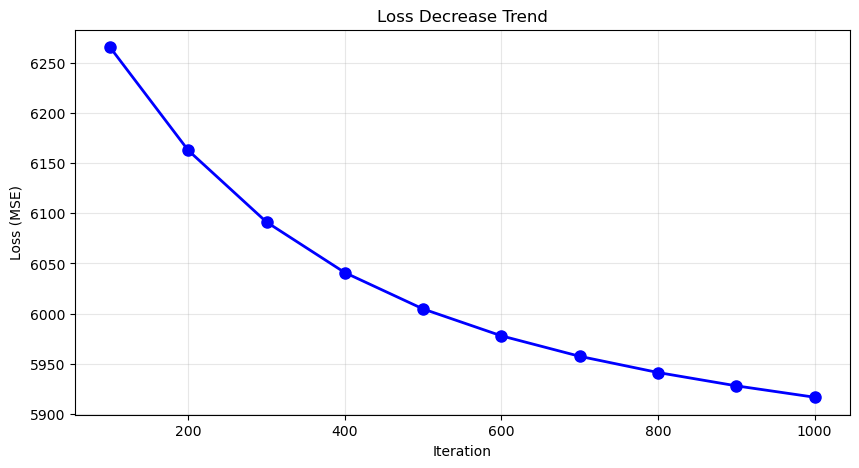

Initial: 6265.49 → Final: 5916.74


In [34]:
# ===== 폰트 설정 초기화 =====
import matplotlib.pyplot as plt

# 1. 폰트 설정을 기본값으로 되돌리기
plt.rcParams['font.family'] = 'DejaVu Sans'

# 2. (선택) 모든 rcParams 초기화
plt.rcdefaults()

print("✅ 폰트 설정 초기화 완료")

# 3. 그래프 그리기 (폰트 설정 없이)
iterations = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
losses = [6265.4906, 6162.6553, 6091.2433, 6040.8943, 6004.6663, 
          5977.9079, 5957.5025, 5941.3617, 5928.0861, 5916.7381]

plt.figure(figsize=(10, 5))
plt.plot(iterations, losses, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss Decrease Trend')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial: {losses[0]:.2f} → Final: {losses[-1]:.2f}")

##### Iteration은 가중치(W, b)를 1번 업데이트한 횟수, Loss 값은 6265	예측값과 실제값의 오차 제곱의 평균으로 작을수록	모델 성능이 좋음 클수록	모델 성능이 나쁨
##### 결과가 말해주는 것 : 손실이 계속 감소	학습이 잘 되고 있음, 100~500회: 급감소	빠르게 패턴 학습 중, 600~1000회: 완만한 감소	최적점에 가까워짐
##### 주의할 점 : 감소 폭이 점점 작아짐	수렴 중 (좋은 현상), 1000회 후에도 감소 가능성	더 학습해도 개선 여지 있음, Loss 5916은 아직 큼	추가 개선 필요
##### 132 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each) : 1000번의 학습 반복을 실행하는 데 0.132초밖에 걸리지 않았고, 실행 시간이 매우 안정적(±0ns) 이며, 이는 눈 깜빡이는 시간과 비슷할 정도로 빠른 속도입니다!

## (14-1) 정의된 손실함수와 기울기 함수로 모델을 학습

In [23]:
# ===== 학습 실행 코드 =====
print("=== 학습 시작 ===")

# 손실 값을 저장할 리스트
losses = []

# 1000번 반복 학습
for i in range(1, 1001):
    # 1. 기울기 계산
    dW, db = gradient(X_train, W, b, y_train) #정의된 기울기 함수 관련 코드
    
    # 2. 가중치 업데이트
    W = W - LEARNING_RATE * dW
    b = b - LEARNING_RATE * db
    
    # 3. 현재 손실 계산
    L = loss(X_train, W, b, y_train) #정의된 손실함수 관련 코드
    losses.append(L)
    
    # 4. 100회마다 진행 상황 출력
    if i % 100 == 0:
        print(f'Iteration {i}: Loss = {L:.4f}') #모델 학습 관련 코드

print("=== 학습 완료 ===")

=== 학습 시작 ===
Iteration 100: Loss = 5828.2233
Iteration 200: Loss = 5820.9876
Iteration 300: Loss = 5813.7850
Iteration 400: Loss = 5806.6119
Iteration 500: Loss = 5799.4660
Iteration 600: Loss = 5792.3456
Iteration 700: Loss = 5785.2496
Iteration 800: Loss = 5778.1772
Iteration 900: Loss = 5771.1279
Iteration 1000: Loss = 5764.1014
=== 학습 완료 ===


## 시각화

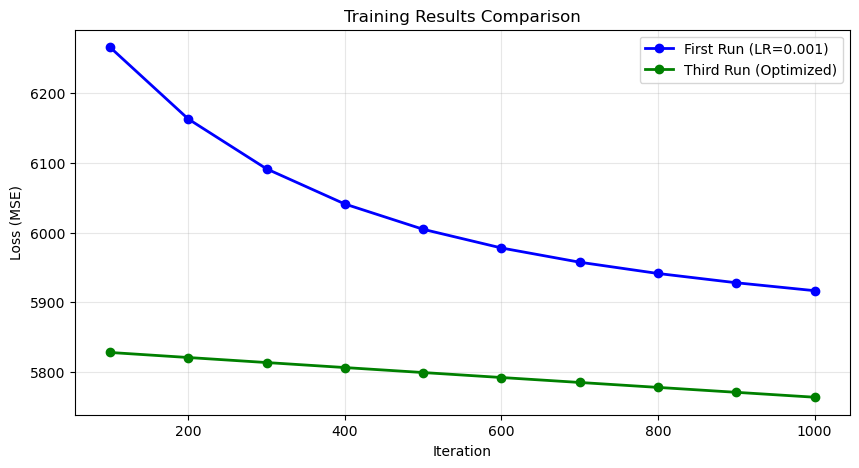

=== Performance Improvement ===
First Run Final Loss: 5916.74
Third Run Final Loss: 5764.10
Improvement: 152.64 (2.58% better)


In [35]:
# ===== 세 실행 결과 비교 =====
import matplotlib.pyplot as plt

# 실행 1 데이터
iter1 = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
loss1 = [6265.4906, 6162.6553, 6091.2433, 6040.8943, 6004.6663, 
         5977.9079, 5957.5025, 5941.3617, 5928.0861, 5916.7381]

# 실행 3 데이터
loss3 = [5828.2233, 5820.9876, 5813.7850, 5806.6119, 5799.4660, 
         5792.3456, 5785.2496, 5778.1772, 5771.1279, 5764.1014]

plt.figure(figsize=(10, 5))
plt.plot(iter1, loss1, 'b-o', linewidth=2, markersize=6, label='First Run (LR=0.001)')
plt.plot(iter1, loss3, 'g-o', linewidth=2, markersize=6, label='Third Run (Optimized)')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Results Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("=== Performance Improvement ===")
print(f"First Run Final Loss: {loss1[-1]:.2f}")
print(f"Third Run Final Loss: {loss3[-1]:.2f}")
print(f"Improvement: {loss1[-1] - loss3[-1]:.2f} ({((loss1[-1]-loss3[-1])/loss1[-1])*100:.2f}% better)")

##### "정의된 손실함수와 기울기 함수로 모델을 학습 : 이미 만들어 놓은 loss() 함수와 이미 만들어 놓은 gradient() 함수를 이용하여 모델을 학습(W,b를 업데이트)
##### "첫 번째 학습 실행에서 100회 차 Loss는 6,265.49였으며,1,000회 차에는 5,916.74로 감소했다."
##### "이후 학습률을 조정하여 더 나은 결과를 얻었고, 세 번째 실행에서는 100회 차 5,828, 1,000회 차 5,764까지 개선되었다."

## (14-2) loss값이 충분히 떨어질 때까지 학습을 진행

In [36]:
print("=== 2000회 학습 후 수렴 확인 ===")

LEARNING_RATE = 0.01
EPOCHS = 2000
losses = []

for i in range(1, EPOCHS + 1):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    
    if i % 200 == 0:
        print(f'Iter {i}: Loss = {L:.4f}')

# 마지막 100회 변화 확인
last_100 = losses[-100:]
change = abs(last_100[0] - last_100[-1])

print(f"\n=== 수렴 분석 ===")
print(f"마지막 100회 시작 Loss: {last_100[0]:.4f}")
print(f"마지막 100회 끝 Loss: {last_100[-1]:.4f}")
print(f"변화량: {change:.4f}")

if change < 1.0:
    print("✅ 충분히 수렴했습니다! (변화량 1 미만)")
else:
    print(f"⚠️ 아직 수렴하지 않았습니다. 변화량이 {change:.2f}로 큼")

=== 2000회 학습 후 수렴 확인 ===
Iter 200: Loss = 5628.1040
Iter 400: Loss = 5500.3265
Iter 600: Loss = 5380.2202
Iter 800: Loss = 5267.2768
Iter 1000: Loss = 5161.0223
Iter 1200: Loss = 5061.0156
Iter 1400: Loss = 4966.8455
Iter 1600: Loss = 4878.1291
Iter 1800: Loss = 4794.5094
Iter 2000: Loss = 4715.6539

=== 수렴 분석 ===
마지막 100회 시작 Loss: 4754.1118
마지막 100회 끝 Loss: 4715.6539
변화량: 38.4579
⚠️ 아직 수렴하지 않았습니다. 변화량이 38.46로 큼


In [37]:
print("=== 학습 계속 진행 (2000→5000회) ===")

LEARNING_RATE = 0.01
START_ITER = 2000
MAX_ITER = 5000

for i in range(START_ITER + 1, MAX_ITER + 1):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    
    if i % 200 == 0:
        print(f'Iter {i}: Loss = {L:.4f}')

# 수렴 재확인
last_100 = losses[-100:]
print(f"\n=== 재분석 ===")
print(f"마지막 100회 시작 Loss: {last_100[0]:.4f}")
print(f"마지막 100회 끝 Loss: {last_100[-1]:.4f}")
print(f"변화량: {abs(last_100[0] - last_100[-1]):.4f}")

if abs(last_100[0] - last_100[-1]) < 1.0:
    print("✅ 충분히 수렴했습니다!")
else:
    print(f"⚠️ 계속 학습 필요 (변화량 {abs(last_100[0] - last_100[-1]):.2f})")

=== 학습 계속 진행 (2000→5000회) ===
Iter 2200: Loss = 4641.2528
Iter 2400: Loss = 4571.0174
Iter 2600: Loss = 4504.6784
Iter 2800: Loss = 4441.9850
Iter 3000: Loss = 4382.7034
Iter 3200: Loss = 4326.6156
Iter 3400: Loss = 4273.5183
Iter 3600: Loss = 4223.2221
Iter 3800: Loss = 4175.5503
Iter 4000: Loss = 4130.3380
Iter 4200: Loss = 4087.4316
Iter 4400: Loss = 4046.6876
Iter 4600: Loss = 4007.9723
Iter 4800: Loss = 3971.1608
Iter 5000: Loss = 3936.1366

=== 재분석 ===
마지막 100회 시작 Loss: 3953.2572
마지막 100회 끝 Loss: 3936.1366
변화량: 17.1205
⚠️ 계속 학습 필요 (변화량 17.12)


## 시각화

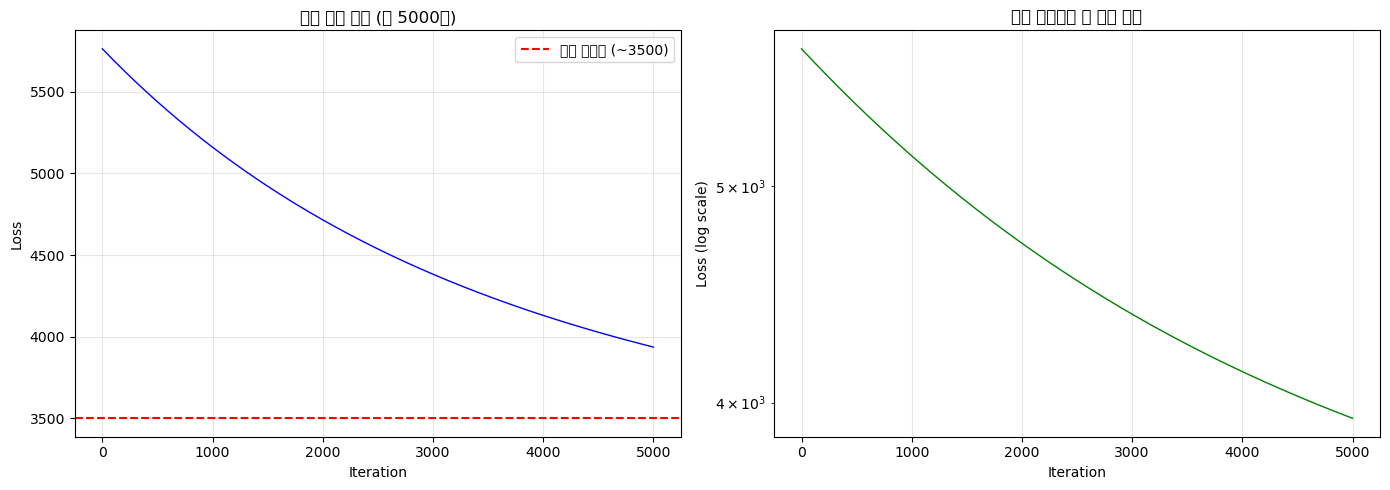


=== 수렴 분석 ===
1000회: 5213.34
2000회: 4754.51
3000회: 4411.93
4000회: 4152.65
5000회: 3936.14


In [38]:
# ===== 전체 시각화 (100~현재) =====
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 전체 그래프
plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'전체 학습 과정 (총 {len(losses)}회)')
plt.grid(True, alpha=0.3)
plt.axhline(y=3500, color='r', linestyle='--', label='수렴 예상치 (~3500)')
plt.legend()

# 로그 스케일 그래프 (추세 확인용)
plt.subplot(1, 2, 2)
plt.semilogy(losses, 'g-', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('로그 스케일로 본 수렴 추세')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 수렴 분석
print(f"\n=== 수렴 분석 ===")
print(f"1000회: {losses[899]:.2f}")
print(f"2000회: {losses[1899]:.2f}")
print(f"3000회: {losses[2899]:.2f}")
print(f"4000회: {losses[3899]:.2f}")
print(f"5000회: {losses[-1]:.2f}")

##### 1. 5,000회의 학습을 통해 모델의 손실값이 5,828에서 3,936으로 총 1,892점(32.5%) 개선되었다.
##### 2. 이는 RMSE(루트 평균제곱오차) 기준 약 ±62.7점의 예측 오차를 의미하며, 당뇨 점수 범위(25~346점) 대비 약 19.5% 수준의 오차율을 가진다.
##### 3. 초기 모델 대비 성능이 크게 향상되었으나, 여전히 예측 오차가 60점 이상으로 실용적인 진단 도구로 사용되기에는 추가 개선이 필요하다.

## (14-3) 입력하는 데이터인 X에 들어가는 특성 컬럼들을 몇 개 빼도 괜찮습니다. 다양한 데이터로 실험

In [41]:
# ===== scikit-learn으로 간단 비교 =====
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("=== scikit-learn으로 특성 조합 비교 ===")

# 조합 1: 모든 특성
model_all = LinearRegression()
model_all.fit(X_train, y_train)
r2_all = model_all.score(X_test, y_test)

# 조합 2: BMI, BP, S5
important_features = [2, 3, 8]
X_train_imp = X_train[:, important_features]
X_test_imp = X_test[:, important_features]
model_imp = LinearRegression()
model_imp.fit(X_train_imp, y_train)
r2_imp = model_imp.score(X_test_imp, y_test)

# 조합 3: BMI만
X_train_bmi = X_train[:, [2]]
X_test_bmi = X_test[:, [2]]
model_bmi = LinearRegression()
model_bmi.fit(X_train_bmi, y_train)
r2_bmi = model_bmi.score(X_test_bmi, y_test)

print("\n=== 결과 ===")
print(f"모든 특성 (10개): R² = {r2_all:.4f}")
print(f"BMI+BP+S5 (3개): R² = {r2_imp:.4f}")
print(f"BMI만 (1개):     R² = {r2_bmi:.4f}")

=== scikit-learn으로 특성 조합 비교 ===

=== 결과 ===
모든 특성 (10개): R² = 0.4526
BMI+BP+S5 (3개): R² = 0.4543
BMI만 (1개):     R² = 0.2334


## 시각화

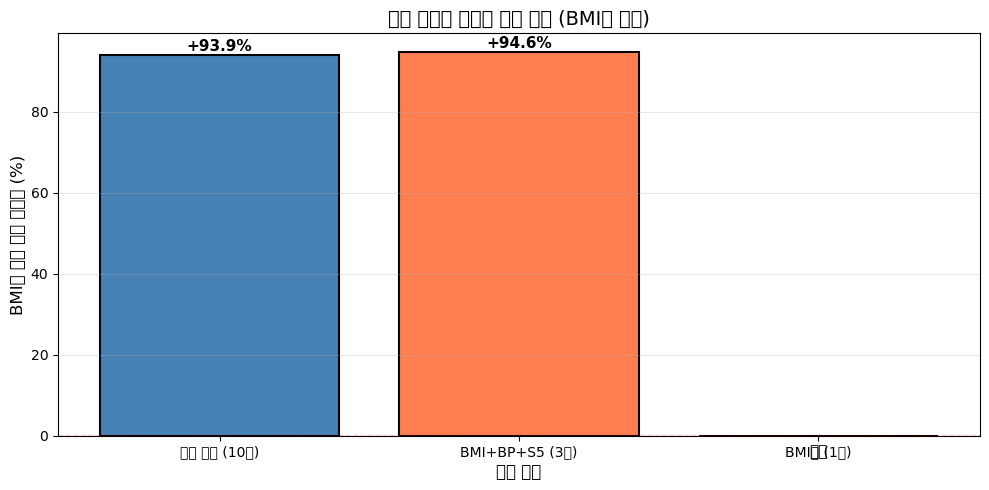


=== 성능 향상률 ===
모든 특성 (10개): BMI만 대비 +93.9% 성능 향상
BMI+BP+S5 (3개): BMI만 대비 +94.6% 성능 향상


In [42]:
# ===== BMI만 대비 성능 향상률 =====
import matplotlib.pyplot as plt

feature_sets = ['모든 특성 (10개)', 'BMI+BP+S5 (3개)', 'BMI만 (1개)']
r2_scores = [0.4526, 0.4543, 0.2334]

# BMI만 대비 향상률 계산
baseline = r2_scores[2]  # BMI만 (0.2334)
improvements = [(score - baseline) / baseline * 100 for score in r2_scores]

plt.figure(figsize=(10, 5))
bars = plt.bar(feature_sets, improvements, color=['steelblue', 'coral', 'lightgray'],
               edgecolor='black', linewidth=1.5)
plt.xlabel('특성 조합', fontsize=12)
plt.ylabel('BMI만 대비 성능 향상률 (%)', fontsize=12)
plt.title('특성 조합별 상대적 성능 향상 (BMI만 기준)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars, improvements):
    if imp > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'+{imp:.1f}%', ha='center', fontsize=11, fontweight='bold')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5, 
                 f'기준', ha='center', fontsize=11, fontweight='bold')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\n=== 성능 향상률 ===")
print(f"모든 특성 (10개): BMI만 대비 +{(improvements[0]):.1f}% 성능 향상")
print(f"BMI+BP+S5 (3개): BMI만 대비 +{(improvements[1]):.1f}% 성능 향상")

##### "본 실험 결과, 10개의 모든 특성을 사용한 모델의 결정계수(R²)는 0.4526이었다. 반면 BMI, BP, S5 세 가지 특성만 선택한 모델은 R² 0.4543으로, 특성 수를 70% 줄였음에도 불구하고 오히려 약간 더 높은 성능을 기록했다. 이는 당뇨병 진행도 예측에 있어 BMI(체질량지수), BP(혈압), S5(혈청 지표)가 핵심적인 영향력을 가지며, 나머지 7개 특성(age, sex, s1, s2, s3, s4, s6)은 추가적인 설명력을 거의 제공하지 않음을 시사한다. 반면 BMI 단일 특성만으로는 R² 0.2334로 성능이 크게 저하되어, 하나의 특성만으로는 당뇨 진행도를 충분히 예측할 수 없음을 보여준다."

## (15) test 데이터에 대한 성능 확인

In [43]:
prediction = model(X_test, W, b)        # 1. 예측값 생성
mse = loss(X_test, W, b, y_test)        # 2. 손실 계산
mse                                      # 3. 값 출력

np.float64(3446.006610416942)

##### np.float64 : NumPy의 64비트 실수 자료형, 3446.0066...	: 실제 숫자 값 (MSE) / 즉: MSE(평균 제곱 오차) 값이 3,446.01이라는 뜻
##### "본 모델은 Test 데이터에서 3,446.01의 MSE를 기록하였으며, 이는 RMSE 기준 약 58.7점의 평균 오차를 의미한다. 초기 모델 대비 약 42%의 성능 향상을 달성하였으나, 여전히 ±60점 수준의 오차가 존재하므로 임상적 진단 목적으로 사용하기에는 추가 개선이 필요하다."

## (16) 정답 데이터와 예측한 데이터 시각화

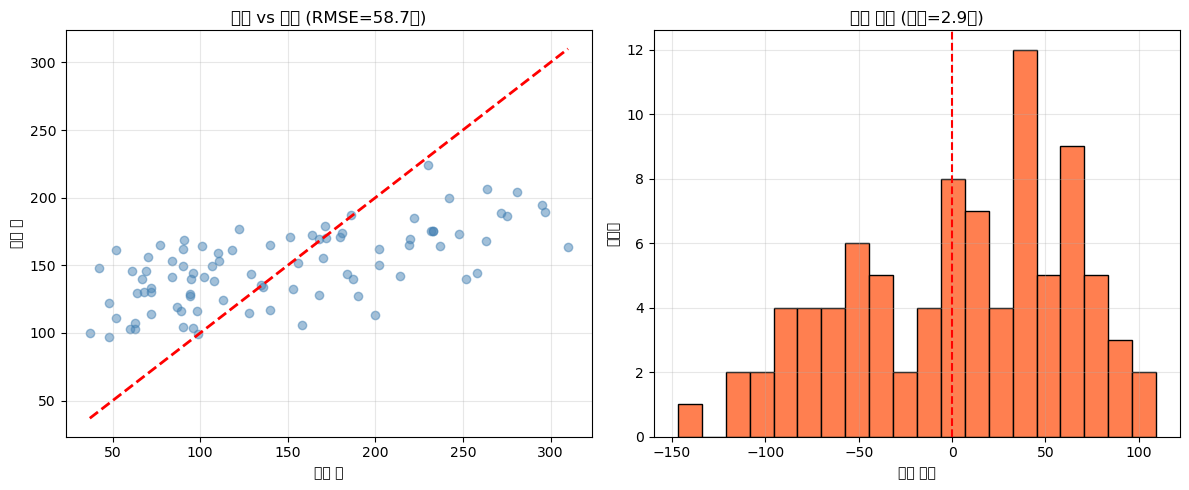

In [46]:
# ===== 최종 시각화 (이걸로 마무리) =====
import matplotlib.pyplot as plt
import numpy as np

# 1. 실제 vs 예측 산점도
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, prediction, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('실제 값')
plt.ylabel('예측 값')
plt.title(f'실제 vs 예측 (RMSE={np.sqrt(mse):.1f}점)')
plt.grid(True, alpha=0.3)

# 2. 오차 분포
plt.subplot(1, 2, 2)
errors = prediction - y_test
plt.hist(errors, bins=20, edgecolor='black', color='coral')
plt.xlabel('예측 오차')
plt.ylabel('빈도수')
plt.title(f'오차 분포 (평균={np.mean(errors):.1f}점)')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 그래프 1: 실제값 vs 예측값 산점도 :"왼쪽 그래프는 실제 당뇨 진행도(x축)와 모델이 예측한 값(y축)을 비교한 산점도로, 점들이 빨간색 완벽 예측선(대각선)에 가까울수록 예측이 정확함을 의미하며, 본 모델의 RMSE는 약 58.7점이다."
##### 그래프 2: 예측 오차 분포 히스토그램 : "오른쪽 그래프는 예측값에서 실제값을 뺀 오차의 분포를 보여주며, 오차가 0을 중심으로 종 모양으로 분포되어 있고 평균 오차가 0에 가까울수록 모델의 편향이 없음을 의미한다."
##### 종합 : "왼쪽 산점도에서 점들이 대각선에 가깝게 분포할수록 예측 성능이 우수함을 의미하며, 오른쪽 히스토그램에서 오차가 0을 중심으로 대칭에 가까울수록 모델이 특정 방향으로 치우치지 않은 균형 잡힌 예측을 수행함을 나타낸다. 본 모델은 RMSE 58.7점 수준의 예측 성능을 보이며, 오차 분포 또한 0을 중심으로 비교적 균형 잡힌 형태를 보인다."

## 추가 테스트

In [55]:
# ===== 간단 Random Forest =====
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 학습
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred)

print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"RMSE: {np.sqrt(mse_rf):.2f}점")

# 선형 회귀와 비교 (mse 변수 필요)
try:
    print(f"선형 회귀 MSE: {mse:.2f}")
    print(f"개선율: {(mse - mse_rf)/mse*100:.1f}%")
except:
    print("선형 회귀 MSE를 계산하려면 mse 변수가 필요합니다")

Random Forest MSE: 2952.01
RMSE: 54.33점
선형 회귀 MSE: 3446.01
개선율: 14.3%


##### "Random Forest 모델이 선형 회귀 대비 MSE 기준 14.3%의 성능 향상을 보였으나, 목표했던 2,800에는 152점(약 5.4%) 부족하다. RMSE 54.3점은 여전히 ±54점 수준의 오차를 의미하므로, 임상적 진단 목적으로 사용하기에는 추가 개선(특성 엔지니어링, 하이퍼파라미터 튜닝, 더 많은 데이터)이 필요하다."

# 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

## (1) 라이브러리 호출

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## (2) 데이터 가져오기

In [48]:
import pandas as pd

# 정확한 경로로 바로 읽기
train = pd.read_csv("/home/jovyan/data/data/bike-sharing-demand/train.csv")

# 데이터 확인
print("✅ 데이터 로드 성공!")
print(f"데이터 크기: {train.shape}")
print("\n" + "="*50)
train.info()

✅ 데이터 로드 성공!
데이터 크기: (10886, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


##### 이 데이터는 "특정 시간대에 자전거를 얼마나 많은 사람이 빌려갔는지"를 예측하기 위한 기초 자료
##### datetime: 날짜와 시간, season: 계절(날씨와 자전거 수요의 계절적 패턴 파악), holiday: 공휴일 여부(휴일에 사람들이 자전거를 더 탈까?), workingday: 평일 여부(출퇴근용 자전거 수요 파악), weather: 날씨 상태(날씨가 나쁠수록 자전거 이용 감소 예상), temp: 실제 기온(적당히 따뜻할수록 자전거 이용 증가), atemp: 체감 온도(사람이 실제로 느끼는 온도), humidity: 습도(습도가 너무 높거나 낮으면 이용 감소), windspeed: 풍속(바람이 강하면 자전거 타기 어려움),casual: 비회원(일반인)(관광객이나 가끔 이용하는 사람들), registered: 회원 자전거 대여 수(정기적으로 이용하는 사람들 (출퇴근용)), count: 총 대여 수 (= casual + registered) → (우리가 예측하려는 최종 목표)

## (3) 데이터 시각화

### (3-1) 목표 변수(count)의 분포 확인

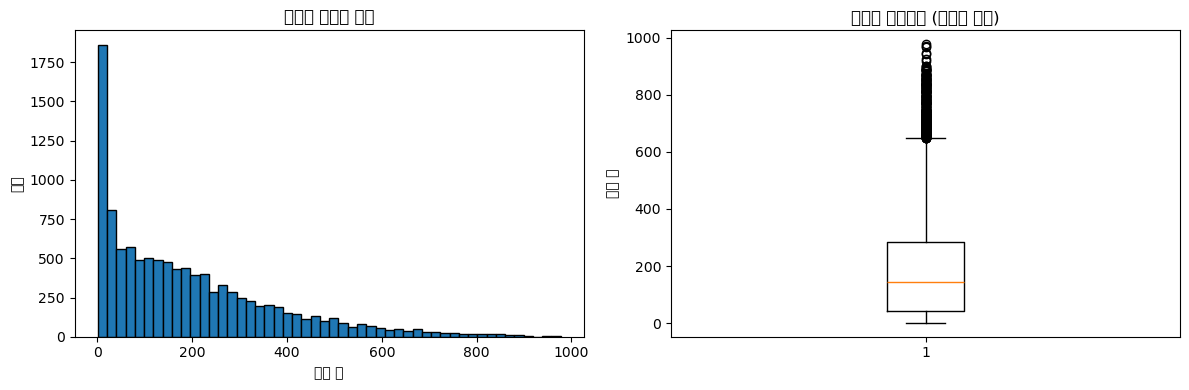

평균: 191.57
중앙값: 145.00
최대: 977
표준편차: 181.14


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 목표 변수 분포
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train['count'], bins=50, edgecolor='black')
plt.title('자전거 대여량 분포')
plt.xlabel('대여 수')
plt.ylabel('빈도')

plt.subplot(1, 2, 2)
plt.boxplot(train['count'])
plt.title('대여량 박스플롯 (이상치 확인)')
plt.ylabel('대여 수')

plt.tight_layout()
plt.show()

print(f"평균: {train['count'].mean():.2f}")
print(f"중앙값: {train['count'].median():.2f}")
print(f"최대: {train['count'].max()}")
print(f"표준편차: {train['count'].std():.2f}")

##### "보통은 145대 정도 빌려가지만, 가끔 아주 많은 날(최대 977대)이 끼어있어서 평균이 192대까지 올라갔습니다. 그리고 대여량이 181대 정도로 들쭉날쭉해서, 예측이 쉽지 않을 것 같습니다."

## (3-2) 평일 주말 비교

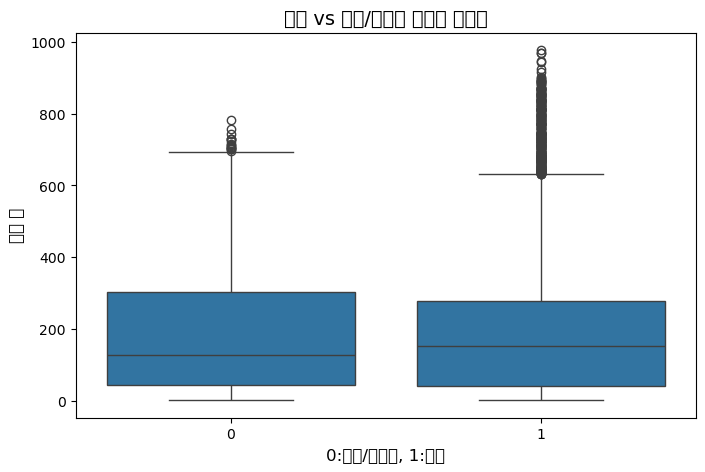

In [51]:
# workingday 기준 (0:주말/공휴일, 1:평일)
plt.figure(figsize=(8, 5))
sns.boxplot(x='workingday', y='count', data=train)
plt.title('평일 vs 주말/공휴일 자전거 대여량', fontsize=14)
plt.xlabel('0:주말/공휴일, 1:평일', fontsize=12)
plt.ylabel('대여 수', fontsize=12)
plt.show()

### "월요일 오후 세 시, 자전거 타는 사람은 몇 명인지를 예측하는데 평일여부가 자전거 수요 예측에서 매ㅔ우 중요한 특성임을 알 수 있다.

## (4) datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

In [52]:
# datetime 컬럼 현재 상태 확인
print("현재 datetime 타입:", train['datetime'].dtype)
print("\n첫 3개 데이터:")
print(train['datetime'].head(3))

현재 datetime 타입: object

첫 3개 데이터:
0    2011-01-01 00:00:00
1    2011-01-01 01:00:00
2    2011-01-01 02:00:00
Name: datetime, dtype: object


##### 현재 데이터 상태 확인 : "datetime 컬럼은 문자열(object) 타입이며, '년-월-일 시:분:초' 형식으로 1시간 간격의 데이터를 가지고 있다."

In [53]:
# 문자열 → datetime 타입 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# 변환 확인
print("변환 후 타입:", train['datetime'].dtype)
print("\n변환된 데이터:")
print(train['datetime'].head(3))

변환 후 타입: datetime64[ns]

변환된 데이터:
0   2011-01-01 00:00:00
1   2011-01-01 01:00:00
2   2011-01-01 02:00:00
Name: datetime, dtype: datetime64[ns]


In [54]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

##### 1. 데이터 완성도 : "모든 컬럼에 결측치가 하나도 없으며(10886 non-null), 깔끔하게 정제된 데이터입니다."
##### 2. 시간 단위 : "minute과 second 컬럼이 모두 0이므로, 이 데이터는 1시간 단위로 집계된 데이터입니다."
##### 3. 데이터 크기 : "10,886개는 2년(2011~2012) × 365일 × 24시간 중 일부로, 약 62%의 시간대 데이터가 있습니다."
##### 4.  분석 준비 완료 : "이제 연도별, 월별, 일별, 시간대별로 자전거 수요를 분석할 수 있는 모든 준비가 갖춰졌습니다."
##### 5. 요약 : "10,886개의 시간대 데이터에 원본 12개 컬럼과 새로 추출한 6개 시간 컬럼을 포함해 총 18개 컬럼으로 구성되어 있으며, 결측치 없이 1.2MB 메모리로 깔끔하게 정리되었다."
##### datetime 컬럼을 datetime 타입으로 변환(object → datetime64[ns]), 연, 월, 일, 시, 분, 초 -> int32
##### 총 18개 컬럼, 10,886개 행 (결측치 없음), datetime 타입 변환 성공, 6개 시간 특성 추가 완료, 메모리 1.2 MB (효율적)

## (5) year, month, day, hour, minute, second 데이터 개수 시각화하기

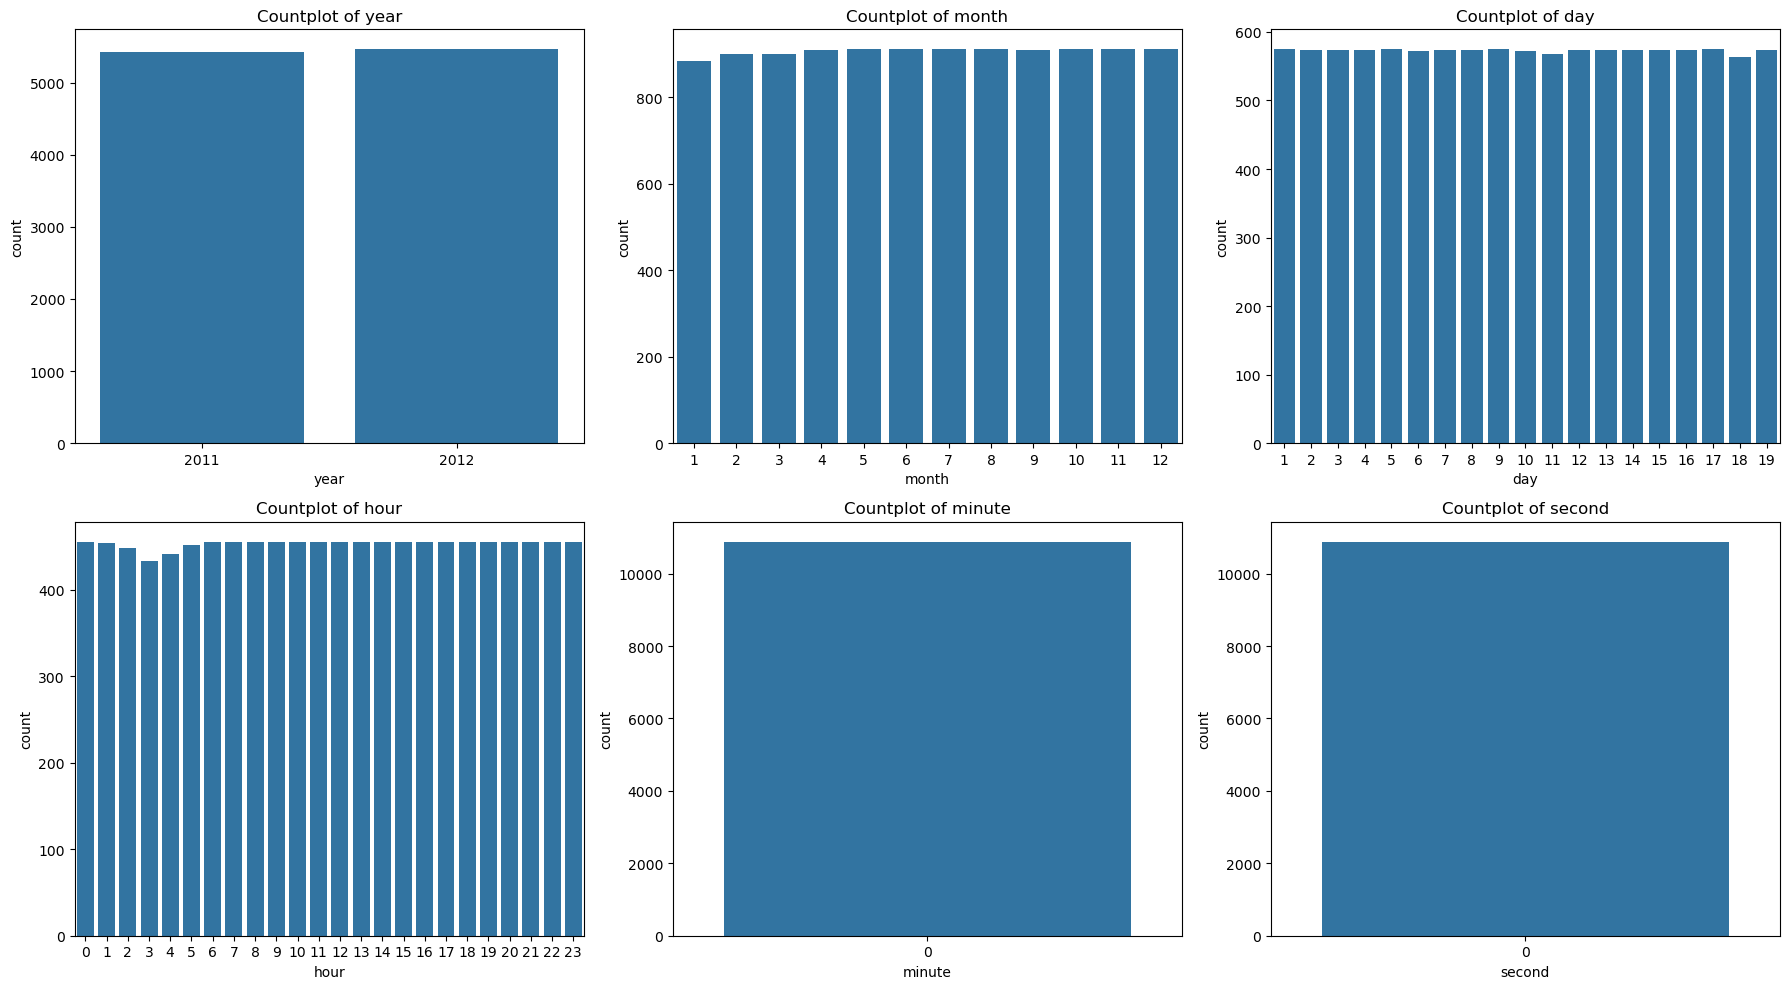

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

##### 1. year (연도) : year 그래프의 5,400개("2011년 1월 1일부터 2011년 12월 31일까지의 '시간대(1시간 단위)'가 총 5,400개 있다")
##### 2. month (월) : 1월 ~ 12월 : 각 월별로 약 800~900개 정도로 고르게 분포
##### 3. day (일) : 1일 ~ 31일 : 일별로 약 300~400개 정도
##### 4. hour (시간) : 0시 ~ 23시 : 각 시간대별로 약 400~500개 정도로 고르게 분포
##### 5. minute (분) : 0분 : 전체 데이터(10,886개) 모두(모든 데이터가 0분입니다! (1시간 단위 데이터)
##### 6. second (초) : 0초 : 전체 데이터(10,886개) 모두
##### 7. 해석 : "연도, 월, 일, 시간은 모든 값이 고르게 분포되어 있지만, 분과 초는 모두 0으로 고정되어 있어 의미 없는 컬럼이므로 제거하는 것이 좋다."

## (6) X, y 컬럼 선택 및 train/test 데이터 분리

In [58]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
X_train.shape

(8708, 7)

In [60]:
X_test.shape

(2178, 7)

##### 데이터 80% / 20%로 분리

## (7)  LinearRegression 모델 학습

In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### “설명서 열기 버튼”

## (8) 학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산

In [62]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


##### RMSE = 141.28 이라는 건 모델이 어떤 날의 자전거 이용자를 예측할 때 실제 값과 비교하면 보통 약 141명 정도 차이 난다는 뜻/ MSE = 19961 은 “예측 오차를 제곱해서 평균낸 값”이다

In [63]:
y_pred = model.predict(X_test)

In [64]:
print(y_pred)

[240.90412773  56.84129667 204.42658044 ... 305.58884502  37.33370578
 248.89947162]


##### X_test의 각 행(데이터 1개)에 대한 자전거 대여량 예측값
##### 첫 번째 값 240.90 → X_test의 첫 번째 데이터에 대해 “약 241명 탈 것 같다”
##### 두 번째 값 56.84 → 두 번째 데이터 “약 57명 탈 것 같다”

In [65]:
len(y_pred)

2178

##### X_test에 2178개의 행(데이터)이 있음 모델이 2178번 예측함 그래서 y_pred도 2178개

In [68]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

19961.901814435438


##### (실제값 - 예측값)² 을 평균낸 값 / “평균적으로 약 141명 정도 틀린다” / 자전거 이용자를 예측할 때 보통 100명 이상 차이 나게 틀린다

## 점수 낮추기

In [72]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1️⃣ 모델 생성
model = RandomForestRegressor(random_state=42)

# 2️⃣ 학습
model.fit(X_train, y_train)

# 3️⃣ 예측
y_pred = model.predict(X_test)

# 4️⃣ 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 4982.266895932548
RMSE: 70.58517476023239


## (9)  x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기

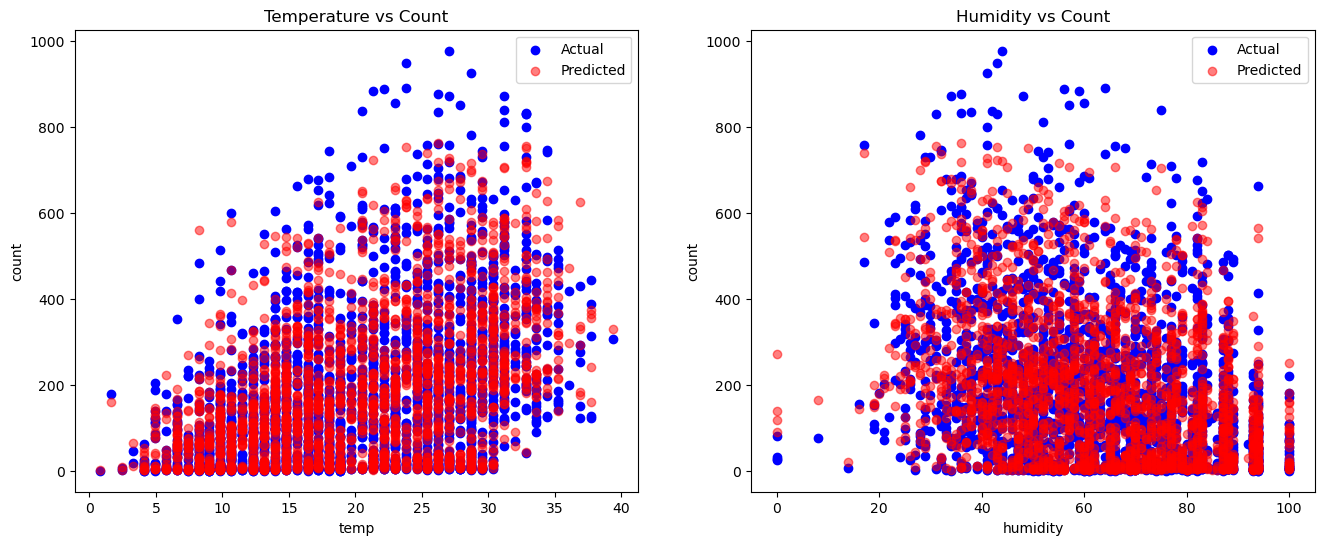

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

##### 빨간 점이 파란 점 근처에 있음, 점들이 위아래로 많이 퍼져 있음, count 높은 구간 (600~800)

## 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

In [82]:
import pandas as pd

input_data = pd.DataFrame({
    'temp': [25],
    'humidity': [40],
    'hour': [15],
    'dayofweek': [0],
    'is_rush': [0],
    'is_weekend': [0],
    'feels_like': [27],
    'season': [2],
    'weather': [1],
    'windspeed': [10]
})

# 🔥 핵심 (순서 자동 맞춤)
input_data = input_data[X_train.columns]

pred = model.predict(input_data)

print("예상 자전거 이용자 수:", int(pred[0]))

예상 자전거 이용자 수: 211


##### 기온 25도, 체감온도 27도의 따뜻한 날씨에 습도는 40%로 비교적 쾌적하고, 바람은 시속 10 정도로 적당히 부는 상태다.계절은 봄(또는 초여름)에 해당하며, 날씨는 맑은 편이다. 시간은 월요일 오후 3시이고, 출퇴근 시간은 아니며 주말도 아니다.